In [1]:
# THIS does not use the electrode remapping - out of date
# more robust with auc for mutiple windows

import os
import mne
import numpy as np
import pandas as pd
from scipy.signal import correlate
from scipy.integrate import simps
from scipy.stats import wilcoxon

from scipy.signal import welch
from scipy.stats import linregress

# -------------------------------------------
# Load files
direct = "C:/EEG_vicon_rest"
files = [os.path.join(direct, file) for file in os.listdir(direct) if file.endswith(".parquet")]
files = sorted(files)

# -------------------------------------------
# Setup
electrodes = ['Fp1', 'Fp2', 'Fpz', 'F3', 'F4', 'F7', 'F8', 'C3', 'C4', 'Cz',
 'O1', 'O2', 'Oz', 'P3', 'P4', 'Pz', 'Fz']

#electrodes = ['C3', 'C4', 'Cz', 'F3', 'F4', 'Fz', 'P3', 'P4', 'Oz']
fs = 200  # Hz
win_size = 2 * fs  # 1 seconds
step_size = 1 * fs  # 1 second




def autocorrelation_auc(signal):
    signal = np.asarray(signal)
    if np.std(signal) == 0:
        return 0.0  # Constant signal
    signal = (signal - np.mean(signal)) / np.std(signal)
    acf = correlate(signal, signal, mode='full')[len(signal) - 1:] / len(signal)
    zero_cross = np.where(np.diff(np.sign(acf)))[0]
    zc_lag = zero_cross[0] if len(zero_cross) > 0 else len(signal) // 2
    if zc_lag < 2 or len(acf[:zc_lag]) < 2:
        return 0.0
    return simps(acf[:zc_lag])

def auc_over_windows(sig):
    aucs = []
    for start in range(0, len(sig) - win_size + 1, step_size):
        window = sig[start:start + win_size]
        if len(window) < win_size:
            continue
        auc = autocorrelation_auc(window)
        if not np.isnan(auc):
            aucs.append(auc)
    return np.mean(aucs) if aucs else np.nan



def spectral_exponent(signal, fs=200, fmin=1, fmax=20):
    """Estimate the spectral exponent (1/f slope) of a signal's power spectrum."""
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    freqs = freqs[1:]  # remove 0 Hz
    psd = psd[1:]

    # Select frequency range of interest
    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return np.nan

    log_freqs = np.log10(freqs[mask])
    log_psd = np.log10(psd[mask])

    slope, intercept, r_value, p_value, std_err = linregress(log_freqs, log_psd)
    return slope  # More negative = stronger 1/f behavior

def spectral_exponent_over_windows(sig, win_size=400, step_size=100, fs=200):
    exponents = []
    for start in range(0, len(sig) - win_size + 1, step_size):
        window = sig[start:start + win_size]
        if len(window) < win_size:
            continue
        exp = spectral_exponent(window, fs=fs)
        if not np.isnan(exp):
            exponents.append(exp)
    return np.mean(exponents) if exponents else np.nan




C:\Users\Peter\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# -------------------------------------------
# Setup: Common electrode set (after mapping)
common_electrodes_base = [
    'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fpz',
    'Fz', 'O1', 'O2', 'Oz', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8'
]
common_electrodes_base = [
    'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 
    'Fz', 'O1', 'O2',  'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8'
]
# Mapping for 10-20 to 10-10
electrode_map_10_20_to_10_10 = {
    'T3': 'T7',
    'T4': 'T8',
    'T5': 'P7',
    'T6': 'P8'
}

fs = 200  # Hz
win_size = 2 * fs
step_size = 1 * fs

# -------------------------------------------
# Collect per-subject AUCs
subject_rest_data = []
subject_block_data = []
subject_fix_data = []
valid_electrodes_global = set(common_electrodes_base)

for filename in files:
    print(f"📂 Processing: {os.path.basename(filename)}")
    df = pd.read_parquet(filename)

    # Detect and rename electrodes if needed
    columns = df.columns
    remapped_cols = {col: electrode_map_10_20_to_10_10[col]
                     for col in columns if col in electrode_map_10_20_to_10_10}
    df = df.rename(columns=remapped_cols)

    # Select electrodes that exist in the current file
    electrodes = [e for e in common_electrodes_base if e in df.columns]

    auc_rest = {}
    auc_block = {}
    auc_fix = {}
    valid_electrodes_all = None

    for i in range(1, 10):
        df_rest = df.query(f'PERIODE == "REST{i}"')
        df_block = df.query(f'BLOCK == {i}')
        df_fix = df.query(f'PERIODE == "preFIX{i}"')

        auc_rest_i = []
        auc_block_i = []
        auc_fix_i = []
        valid_electrodes = []

        for elec in electrodes:
            sig_rest = df_rest[elec].dropna().values[:3000]
            sig_block = df_block[elec].dropna().values[:3000]
            sig_fix = df_fix[elec].dropna().values[:3000]

            if len(sig_rest) < win_size or len(sig_block) < win_size or len(sig_fix) < win_size:
                print('⚠️ short signal:', elec)
                continue

            auc_r = spectral_exponent_over_windows(sig_rest)
            auc_b = spectral_exponent_over_windows(sig_block)
            auc_f = spectral_exponent_over_windows(sig_fix)

            if np.isnan(auc_r) or np.isnan(auc_b) or np.isnan(auc_f):
                print('⚠️ NaN detected:', elec)
                continue

            auc_rest_i.append(auc_r)
            auc_block_i.append(auc_b)
            auc_fix_i.append(auc_f)
            valid_electrodes.append(elec)

        auc_rest[i] = auc_rest_i
        auc_block[i] = auc_block_i
        auc_fix[i] = auc_fix_i

        if valid_electrodes_all is None:
            valid_electrodes_all = set(valid_electrodes)
        else:
            valid_electrodes_all &= set(valid_electrodes)

    valid_electrodes_all = sorted(list(valid_electrodes_all))
    valid_electrodes_global &= set(valid_electrodes_all)

    rest_matrix = np.array([
        [auc_rest[b][valid_electrodes_all.index(e)] for b in range(1, 10)]
        for e in valid_electrodes_all
    ])
    block_matrix = np.array([
        [auc_block[b][valid_electrodes_all.index(e)] for b in range(1, 10)]
        for e in valid_electrodes_all
    ])
    fix_matrix = np.array([
        [auc_fix[b][valid_electrodes_all.index(e)] for b in range(1, 10)]
        for e in valid_electrodes_all
    ])

    subject_rest_data.append(rest_matrix)
    subject_block_data.append(block_matrix)
    subject_fix_data.append(fix_matrix)

# -------------------------------------------
# Harmonize across subjects (only keep electrodes valid for all)
valid_electrodes_global = sorted(list(valid_electrodes_global))
print(f"\n✅ Electrodes valid for ALL subjects: {valid_electrodes_global}")

n_subjects = len(subject_rest_data)
n_electrodes = len(valid_electrodes_global)

rest_all = np.stack([
    subj[[valid_electrodes_global.index(e) for e in valid_electrodes_global], :]
    for subj in subject_rest_data
])
block_all = np.stack([
    subj[[valid_electrodes_global.index(e) for e in valid_electrodes_global], :]
    for subj in subject_block_data
])
fix_all = np.stack([
    subj[[valid_electrodes_global.index(e) for e in valid_electrodes_global], :]
    for subj in subject_fix_data
])


📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Adrien.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Ana.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Antoine.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Camila.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Charlene.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Denis.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Denis2.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Ko.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Louise.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Mael.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Patrice.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Pauline.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Pierre.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Sophie.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Vincent.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Yuki.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Yuyang.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXB

In [20]:
# -------------------------------------------
# Group-level statistics
rest_mean_per_elec = np.mean(rest_all, axis=(0, 2))
block_mean_per_elec = np.mean(block_all, axis=(0, 2))
fix_mean_per_elec = np.mean(fix_all, axis=(0, 2))
diff_mean_per_elec = block_mean_per_elec - rest_mean_per_elec

p_values = []
significant = []

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    stat, p = wilcoxon(block_per_subj, rest_per_subj)
    p_values.append(p)
    significant.append(p < 0.05)

# -------------------------------------------
# Summary table
print("\n📊 Group-level Summary Table:")
print(f"{'Electrode':<8} {'FIX_mean':>10} {'REST_mean':>10} {'BLOCK_mean':>12} {'Diff':>10} {'p-value':>10} {'Signif.':>8}")
print("-" * 60)

for e, f, r, b, d, p, s in zip(valid_electrodes_global,  fix_mean_per_elec, rest_mean_per_elec, block_mean_per_elec, diff_mean_per_elec, p_values, significant):
    star = '*' if s else ''
    print(f"{e:<8}  {f:10.4f}{r:10.4f} {b:12.4f} {d:10.4f} {p:10.4f} {star:>8}")


📊 Group-level Summary Table:
Electrode   FIX_mean  REST_mean   BLOCK_mean       Diff    p-value  Signif.
------------------------------------------------------------
C3           -0.8197   -0.8153      -1.0619    -0.2466     0.0002        *
C4           -0.7464   -0.7883      -1.0301    -0.2418     0.0008        *
Cz           -0.9340   -0.9146      -1.1744    -0.2598     0.0000        *
F3           -0.8954   -0.9374      -1.1000    -0.1626     0.0047        *
F4           -0.8562   -0.8863      -1.0724    -0.1860     0.0028        *
F7           -0.9693   -1.1068      -1.1881    -0.0814     0.2288         
F8           -0.9400   -1.0929      -1.1624    -0.0696     0.3465         
Fp1          -1.0029   -1.1696      -1.1924    -0.0227     0.3692         
Fp2          -0.9439   -1.1564      -1.1294     0.0270     0.9661         
Fz           -0.9979   -0.9941      -1.2153    -0.2212     0.0000        *
O1           -0.9473   -1.0212      -1.1082    -0.0870     0.0665         
O2      

In [21]:
print(df_rest.shape[0])
print(df_rest[elec].dropna().shape[0])
print(df_block.shape[0])
print(df_block[elec].dropna().shape[0])

6000
6000
16748
16748


C:\Users\Peter\AppData\Local\Temp\ipykernel_31896\3994599674.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


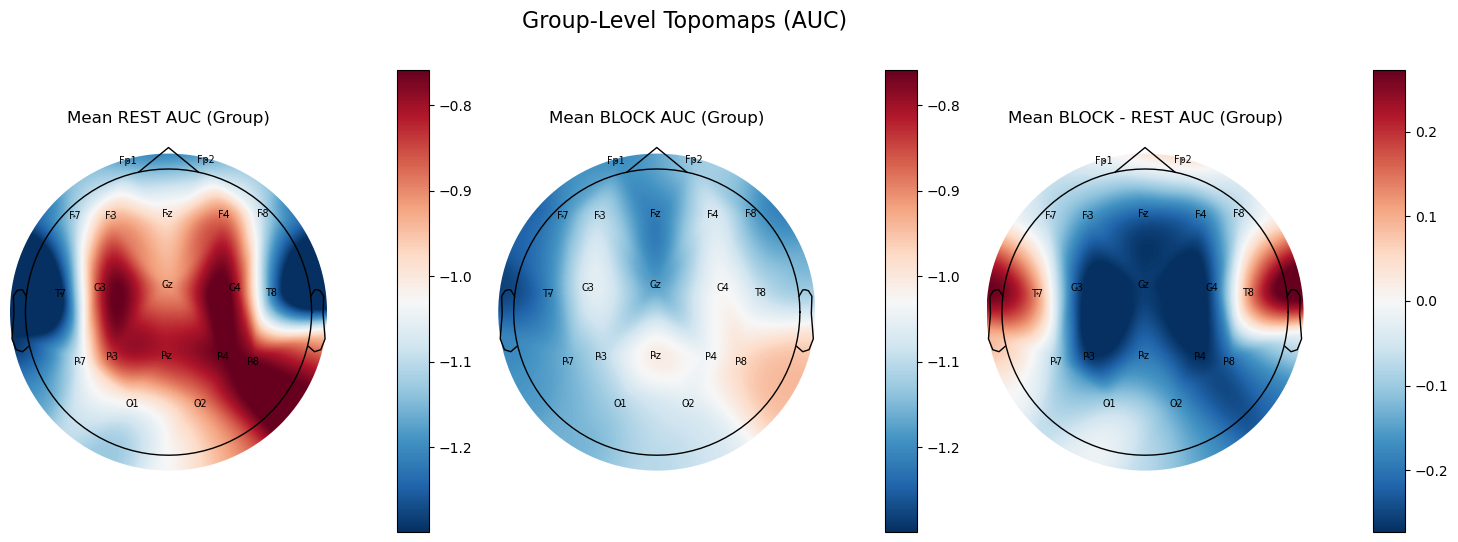

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# -------------------------------------------

# Create MNE info and layout
info = mne.create_info(ch_names=valid_electrodes_all, sfreq=1000, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

layout = mne.channels.make_eeg_layout(info)
pos = layout.pos[:, :2]

# Shared colormap limits for consistent scaling
all_vals = np.concatenate([rest_mean_per_elec, block_mean_per_elec])
vmin = all_vals.min()
vmax = all_vals.max()

# For difference map (BLOCK - REST), use symmetric scale centered at 0
diff_abs_max = np.max(np.abs(diff_mean_per_elec))
vlim_diff = (-diff_abs_max, diff_abs_max)

# -------------------------------------------
# Group Topomaps with shared color scales
titles = ['Mean REST AUC (Group)', 'Mean BLOCK AUC (Group)', 'Mean BLOCK - REST AUC (Group)']
data_list = [rest_mean_per_elec, block_mean_per_elec, diff_mean_per_elec]
vlims = [(vmin, vmax), (vmin, vmax), vlim_diff]

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 6, width_ratios=[10, 1, 10, 1, 10, 1], wspace=0.4)

for i in range(3):
    ax = fig.add_subplot(gs[0, i*2])
    cax = fig.add_subplot(gs[0, i*2 + 1])

    im, _ = mne.viz.plot_topomap(
        data_list[i],
        info,
        axes=ax,
        show=False,
        vlim=vlims[i],  # ✅ correct keyword here
        names=valid_electrodes_global,
        contours=0,
        cmap='RdBu_r'  # <-- add this line to change colormap

    )
    ax.set_title(titles[i])
    plt.colorbar(im, cax=cax)

plt.suptitle("Group-Level Topomaps (AUC)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


C:\Users\Peter\AppData\Local\Temp\ipykernel_31896\3032465411.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


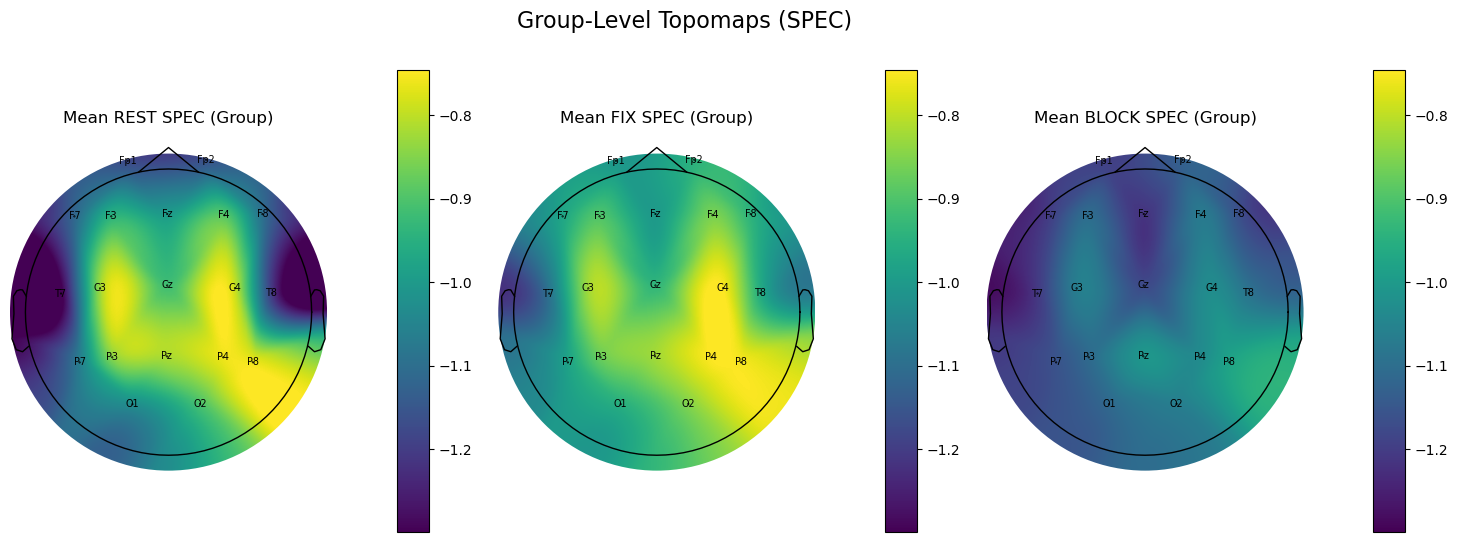

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# -------------------------------------------

# Create MNE info and layout
info = mne.create_info(ch_names=valid_electrodes_all, sfreq=200, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

layout = mne.channels.make_eeg_layout(info)
pos = layout.pos[:, :2]

# Shared colormap limits for consistent scaling
all_vals = np.concatenate([rest_mean_per_elec, block_mean_per_elec, fix_mean_per_elec])
vmin = all_vals.min()
vmax = all_vals.max()


# -------------------------------------------
# Group Topomaps with shared color scales
titles = ['Mean REST SPEC (Group)', 'Mean FIX SPEC (Group)', 'Mean BLOCK SPEC (Group)']
data_list = [rest_mean_per_elec, fix_mean_per_elec, block_mean_per_elec]
vlims = [(vmin, vmax), (vmin, vmax), (vmin, vmax)]

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 6, width_ratios=[10, 1, 10, 1, 10, 1], wspace=0.4)

for i in range(3):
    ax = fig.add_subplot(gs[0, i*2])
    cax = fig.add_subplot(gs[0, i*2 + 1])

    im, _ = mne.viz.plot_topomap(
        data_list[i],
        info,
        axes=ax,
        show=False,
        vlim=vlims[i],  # ✅ correct keyword here
        names=valid_electrodes_global,
        contours=0,
        cmap= 'viridis'#'RdBu_r'  # <-- add this line to change colormap

    )
    ax.set_title(titles[i])
    plt.colorbar(im, cax=cax)

plt.suptitle("Group-Level Topomaps (SPEC)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


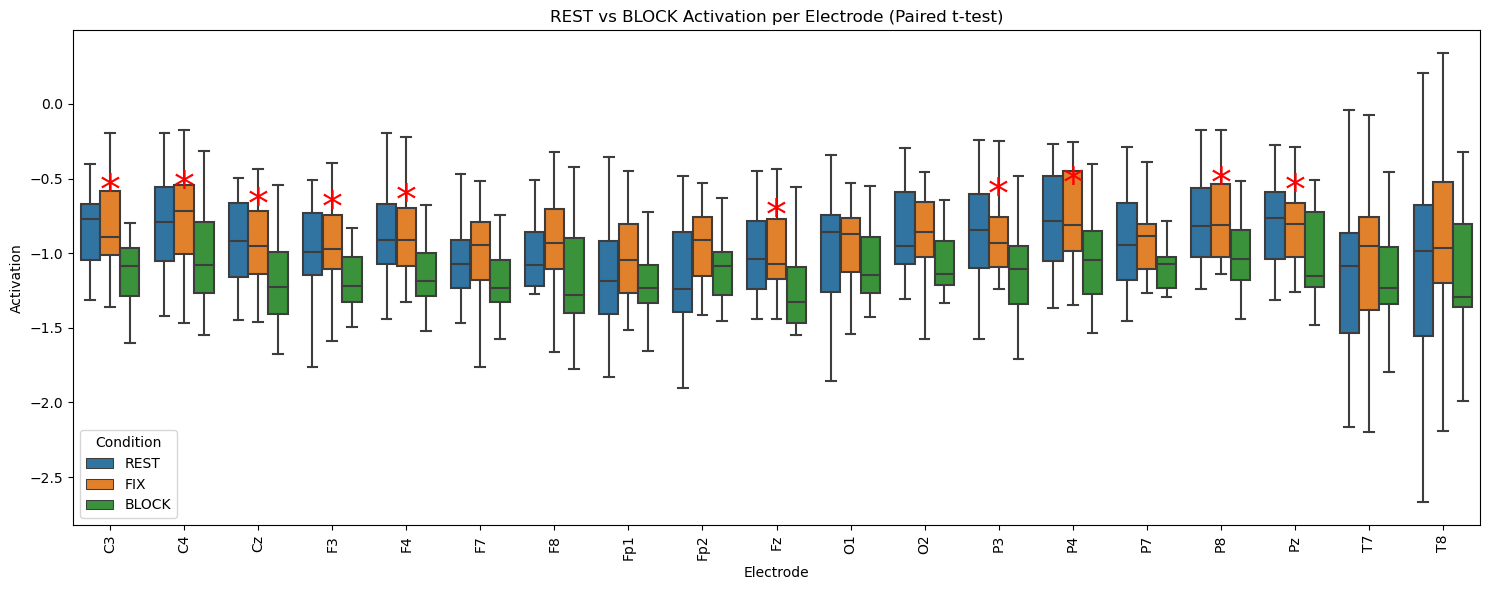

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from scipy.signal import correlate
from scipy.integrate import simps
import numpy as np
import pandas as pd

#sns.set(style="whitegrid")

# Assuming you already have these:
# - rest_all: shape (n_subjects, n_electrodes, n_timepoints)
# - fix_all:  same shape
# - block_all: same shape
# - electrodes: list of length n_electrodes with electrode names

n_electrodes = rest_all.shape[1]
p_values = []
significant = []

# Collect data
data = []
labels = []
electrode_ids = []

# For plotting stars
mean_activation = []

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    # Store for plotting, using actual electrode names
    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrode_ids.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrode_ids.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrode_ids.extend([electrodes[e]] * len(block_per_subj))

    # Paired t-test (BLOCK vs REST)
    stat, p = ttest_rel(block_per_subj, rest_per_subj)
    p_values.append(p)
    significant.append(p < 0.05)

    # For star plotting
    mean_activation.append(max(np.mean(rest_per_subj), np.mean(block_per_subj)))

# Create DataFrame for seaborn
df = pd.DataFrame({
    'Activation': data,
    'Condition': labels,
    'Electrode': electrode_ids
})

# Plot
plt.figure(figsize=(15, 6))
ax = sns.boxplot(data=df, x='Electrode', y='Activation', hue='Condition', showfliers=False)
plt.title('REST vs BLOCK Activation per Electrode (Paired t-test)')
plt.xticks(rotation=90)

# Add significance stars
for i, sig in enumerate(significant):
    if sig:
        y = mean_activation[i] + 0.1 * np.abs(mean_activation[i])  # small offset
        ax.text(i, y, '*', ha='center', va='bottom', color='red', fontsize=30)

plt.tight_layout()
plt.show()


In [25]:
for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    # Store for plotting
    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrode_ids.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrode_ids.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrode_ids.extend([electrodes[e]] * len(block_per_subj))

    # Paired t-test
    stat, p = ttest_rel(block_per_subj, rest_per_subj)
    p_values.append(p)
    significant.append(p < 0.05)

    # For star plotting
    mean_activation.append(max(np.mean(rest_per_subj), np.mean(block_per_subj)))


In [26]:
electrode_names=electrodes

In [27]:
import pingouin as pg
import pandas as pd

# Format data as a long-format DataFrame
# Each row = (subject, electrode, condition, value)

n_subjects = rest_all.shape[0]
rows = []

for subj in range(n_subjects):
    for e in range(n_electrodes):
        rest_val = rest_all[subj, e, :].mean()
        block_val = block_all[subj, e, :].mean()
        fix_val = fix_all[subj, e, :].mean()
        rows.append([subj, electrode_names[e], 'REST', rest_val])
        rows.append([subj, electrode_names[e], 'FIX', fix_val])
        rows.append([subj, electrode_names[e], 'BLOCK', block_val])

df_anova = pd.DataFrame(rows, columns=['Subject', 'Electrode', 'Condition', 'Activation'])

# Run repeated-measures ANOVA
aov = pg.rm_anova(data=df_anova, dv='Activation', within=['Condition', 'Electrode'], subject='Subject', detailed=True)
print(aov)


                  Source         SS  ddof1  ddof2        MS          F  \
0              Condition   7.632677      2     34  3.816339  11.416771   
1              Electrode  10.516146     18    306  0.584230   3.004491   
2  Condition * Electrode   2.635167     36    612  0.073199   3.086822   

          p-unc  p-GG-corr       ng2       eps  
0  1.610131e-04   0.000397  0.047767  0.853276  
1  5.179889e-05   0.027200  0.064645  0.208133  
2  1.178330e-08   0.025218  0.017024  0.101915  


C:\Users\Peter\anaconda3\lib\site-packages\pingouin\distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


In [28]:
import pandas as pd
import pingouin as pg

# Define your updated groups
group_1 = ['F3', 'F4', 'Fz']
group_2 = ['C3', 'C4', 'Cz']
group_3 = ['P3', 'P4', 'Pz']
group_4 = ['O1', 'O2', 'Oz']

# Define your updated groups
group_1 = ['F3', 'F4', 'Fz']
group_2 = ['C3', 'C4', 'Cz']
group_3 = ['P3', 'P4', 'P7']
group_4 = ['O1', 'O2']


electrode_to_group = {}
for name in group_1:
    electrode_to_group[name] = 'Frontal'
for name in group_2:
    electrode_to_group[name] = 'Central'
for name in group_3:
    electrode_to_group[name] = 'Parietal'
for name in group_4:
    electrode_to_group[name] = 'Occipital'
# Build list of rows for DataFrame
rows = []
n_subjects = rest_all.shape[0]

for subj in range(n_subjects):
    for group in ['Frontal', 'Central', 'Parietal', 'Occipital']:
        # Find electrode indices belonging to this group
        group_inds = [i for i, name in enumerate(electrode_names) if name in electrode_to_group and electrode_to_group[name] == group]
        
        if not group_inds:
            continue  # skip if no matching electrodes

        rest_val = rest_all[subj, group_inds, :].mean()
        fix_val = fix_all[subj, group_inds, :].mean()
        block_val = block_all[subj, group_inds, :].mean()

        rows.append([subj, group, 'REST', rest_val])
        rows.append([subj, group, 'FIX', fix_val])
        rows.append([subj, group, 'BLOCK', block_val])

# Create long-form DataFrame
df = pd.DataFrame(rows, columns=['Subject', 'ElectrodeGroup', 'Condition', 'Activation'])

# Run repeated-measures ANOVA
aov = pg.rm_anova(
    data=df,
    dv='Activation',
    within=['Condition', 'ElectrodeGroup'],
    subject='Subject',
    detailed=True
)

print(aov)


                       Source        SS  ddof1  ddof2        MS          F  \
0                   Condition  2.108531      2     34  1.054266  16.429187   
1              ElectrodeGroup  0.180823      3     51  0.060274   0.732194   
2  Condition * ElectrodeGroup  0.076358      6    102  0.012726   0.922729   

      p-unc  p-GG-corr       ng2       eps  
0  0.000010   0.000101  0.089258  0.737956  
1  0.537597   0.486522  0.008335  0.657058  
2  0.481950   0.401690  0.003537  0.310339  


C:\Users\Peter\anaconda3\lib\site-packages\pingouin\distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


In [29]:
for group in ['Frontal', 'Central', 'Parietal','Occipital']:
    group_rows = df[df['ElectrodeGroup'] == group]
    posthoc_group = pg.pairwise_tests(
        data=group_rows,
        dv='Activation',
        within='Condition',
        subject='Subject',
        parametric=True,
        padjust='fdr_bh'
    )
    print(f"\n--- {group} ---")
    # Print only relevant columns that exist
    available_cols = posthoc_group.columns
    cols_to_show = [col for col in ['A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'p-adjust'] if col in available_cols]
    print(posthoc_group[cols_to_show])



--- Frontal ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX -4.791351  17.0  0.000170  0.000510   fdr_bh
1  BLOCK  REST -3.982714  17.0  0.000963  0.001444   fdr_bh
2    FIX  REST  0.658432  17.0  0.519079  0.519079   fdr_bh

--- Central ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX -5.985911  17.0  0.000015  0.000044   fdr_bh
1  BLOCK  REST -5.215908  17.0  0.000070  0.000105   fdr_bh
2    FIX  REST  0.187335  17.0  0.853616  0.853616   fdr_bh

--- Parietal ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX -6.040035  17.0  0.000013  0.000040   fdr_bh
1  BLOCK  REST -3.489357  17.0  0.002808  0.004212   fdr_bh
2    FIX  REST  0.457203  17.0  0.653314  0.653314   fdr_bh

--- Occipital ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX -3.922924  17.0  0.001096  0.003287   fdr_bh
1  BLOCK  REST -1.381575  17.0  0.184991  0.277487   fdr_bh
2    FIX  REST  0.753416  17.

In [30]:
print(posthoc_group.columns)

Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future vers

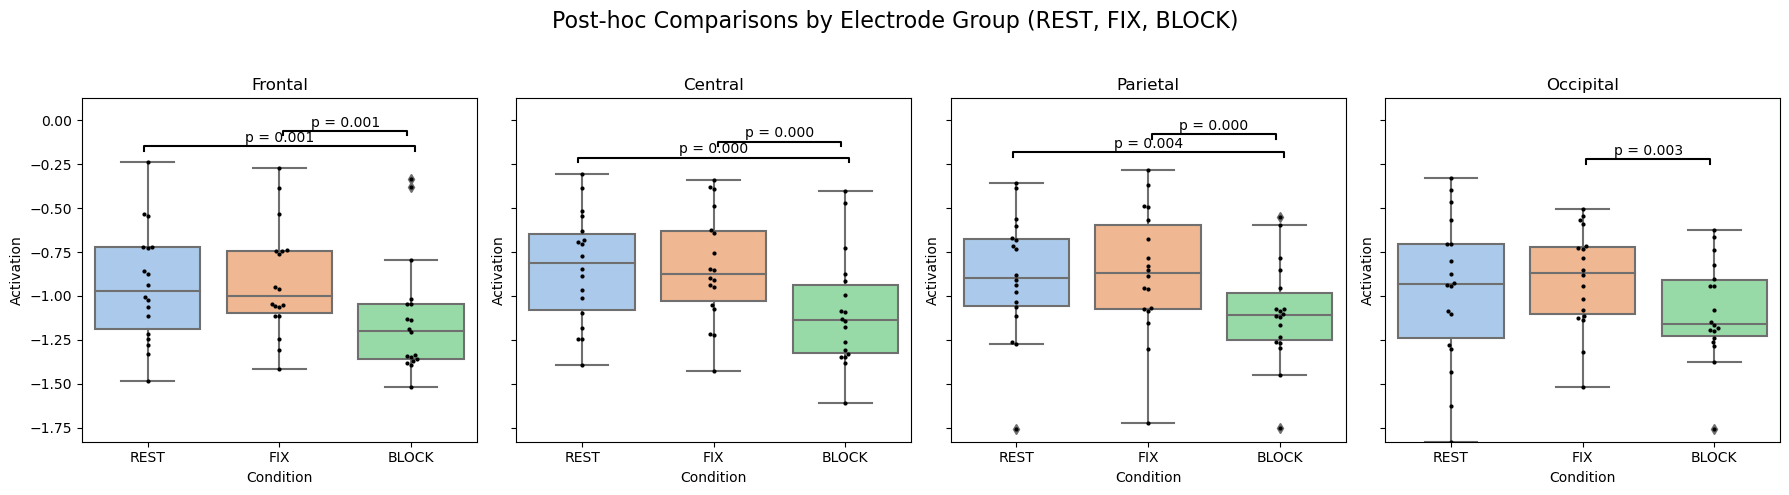

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

#sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
condition_order = ['REST', 'FIX', 'BLOCK']

for i, group in enumerate(['Frontal', 'Central', 'Parietal', 'Occipital']):
    group_rows = df[df['ElectrodeGroup'] == group]
    complete_subjects = group_rows.groupby('Subject')['Condition'].nunique()
    complete_subjects = complete_subjects[complete_subjects == 3].index
    group_rows = group_rows[group_rows['Subject'].isin(complete_subjects)]

    posthoc_group = pg.pairwise_tests(
        data=group_rows,
        dv='Activation',
        within='Condition',
        subject='Subject',
        parametric=True,
        padjust='fdr_bh'
    )

    ax = axes[i]
    sns.boxplot(data=group_rows, x='Condition', y='Activation', ax=ax, palette='pastel', order=condition_order)
    sns.swarmplot(data=group_rows, x='Condition', y='Activation', ax=ax, color='black', size=3, order=condition_order)
    ax.set_title(f'{group}')

    comparisons = [('REST', 'FIX'), ('REST', 'BLOCK'), ('BLOCK', 'FIX')]
    y_max = group_rows['Activation'].max()
    y_min = group_rows['Activation'].min()
    y_range = y_max - y_min

    # Reserve 30% extra space at the top for significance bars
    ax.set_ylim(y_min, y_max + abs(0.3 * y_range))

    base = y_max + 0.05 * y_range
    spacing = 0.07 * y_range  # vertical space between bars
    jitter = 0.03  # horizontal offset for vertical lines

    current_bar = 0
    for cond1, cond2 in comparisons:
        row = posthoc_group[
            ((posthoc_group['A'] == cond1) & (posthoc_group['B'] == cond2)) |
            ((posthoc_group['A'] == cond2) & (posthoc_group['B'] == cond1))
        ]
        if not row.empty:
            pval_corr = row['p-corr'].values[0]
            if pval_corr < 0.05:
                x1 = condition_order.index(cond1)
                x2 = condition_order.index(cond2)
                x_center = (x1 + x2) / 2
                y = base + current_bar * spacing

                # Horizontal bracket with jittered vertical lines
                ax.plot([x1 - jitter, x1 - jitter, x2 + jitter, x2 + jitter],
                        [y, y + 0.02 * y_range, y + 0.02 * y_range, y],
                        color='black', linewidth=1.5)

                # Annotated p-value
                ax.text(x_center, y + 0.025 * y_range, f"p = {pval_corr:.3f}", ha='center', va='bottom', fontsize=10)
                current_bar += 1

plt.suptitle('Post-hoc Comparisons by Electrode Group (REST, FIX, BLOCK)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future vers

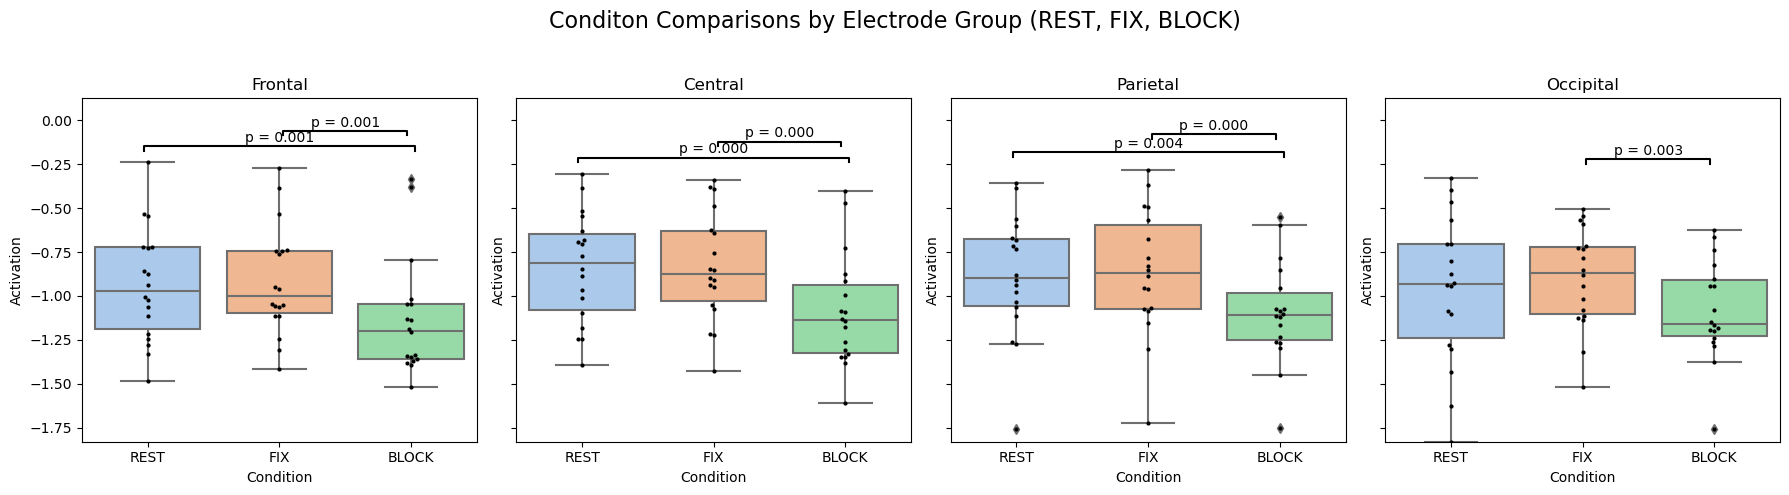

C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


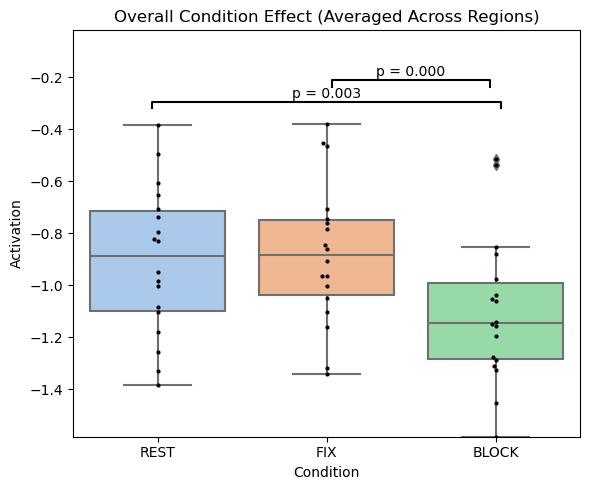

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import pandas as pd

# === First figure: Electrode group comparisons ===
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
condition_order = ['REST', 'FIX', 'BLOCK']

for i, group in enumerate(['Frontal', 'Central', 'Parietal', 'Occipital']):
    group_rows = df[df['ElectrodeGroup'] == group]
    complete_subjects = group_rows.groupby('Subject')['Condition'].nunique()
    complete_subjects = complete_subjects[complete_subjects == 3].index
    group_rows = group_rows[group_rows['Subject'].isin(complete_subjects)]

    posthoc_group = pg.pairwise_tests(
        data=group_rows,
        dv='Activation',
        within='Condition',
        subject='Subject',
        parametric=True,
        padjust='fdr_bh'
    )

    ax = axes[i]
    sns.boxplot(data=group_rows, x='Condition', y='Activation', ax=ax, palette='pastel', order=condition_order)
    sns.swarmplot(data=group_rows, x='Condition', y='Activation', ax=ax, color='black', size=3, order=condition_order)
    ax.set_title(f'{group}')

    comparisons = [('REST', 'FIX'), ('REST', 'BLOCK'), ('BLOCK', 'FIX')]
    y_max = group_rows['Activation'].max()
    y_min = group_rows['Activation'].min()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + 0.3 * y_range)

    base = y_max + 0.05 * y_range
    spacing = 0.07 * y_range
    jitter = 0.03
    current_bar = 0

    for cond1, cond2 in comparisons:
        row = posthoc_group[
            ((posthoc_group['A'] == cond1) & (posthoc_group['B'] == cond2)) |
            ((posthoc_group['A'] == cond2) & (posthoc_group['B'] == cond1))
        ]
        if not row.empty:
            pval_corr = row['p-corr'].values[0]
            if pval_corr < 0.05:
                x1 = condition_order.index(cond1)
                x2 = condition_order.index(cond2)
                x_center = (x1 + x2) / 2
                y = base + current_bar * spacing
                ax.plot([x1 - jitter, x1 - jitter, x2 + jitter, x2 + jitter],
                        [y, y + 0.02 * y_range, y + 0.02 * y_range, y],
                        color='black', linewidth=1.5)
                ax.text(x_center, y + 0.025 * y_range, f"p = {pval_corr:.3f}", ha='center', va='bottom', fontsize=10)
                current_bar += 1

plt.suptitle('Conditon Comparisons by Electrode Group (REST, FIX, BLOCK)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === Second figure: Overall condition effect ===
# Only subjects who have all 3 conditions
overall_rows = df.copy()
complete_subjects = overall_rows.groupby('Subject')['Condition'].nunique()
complete_subjects = complete_subjects[complete_subjects == 3].index
overall_rows = overall_rows[overall_rows['Subject'].isin(complete_subjects)]

# Mean Activation across electrode groups per Subject x Condition
overall_mean = (overall_rows.groupby(['Subject', 'Condition'])['Activation']
                .mean()
                .reset_index())

# Post-hoc comparisons
posthoc_overall = pg.pairwise_tests(
    data=overall_mean,
    dv='Activation',
    within='Condition',
    subject='Subject',
    parametric=True,
    padjust='fdr_bh'
)

# Create a new figure
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=overall_mean, x='Condition', y='Activation', ax=ax, palette='pastel', order=condition_order)
sns.swarmplot(data=overall_mean, x='Condition', y='Activation', ax=ax, color='black', size=3, order=condition_order)
ax.set_title('Overall Condition Effect (Averaged Across Regions)')

y_max = overall_mean['Activation'].max()
y_min = overall_mean['Activation'].min()
y_range = y_max - y_min
ax.set_ylim(y_min, y_max + 0.3 * y_range)

base = y_max + 0.05 * y_range
spacing = 0.07 * y_range
jitter = 0.03
current_bar = 0

for cond1, cond2 in comparisons:
    row = posthoc_overall[
        ((posthoc_overall['A'] == cond1) & (posthoc_overall['B'] == cond2)) |
        ((posthoc_overall['A'] == cond2) & (posthoc_overall['B'] == cond1))
    ]
    if not row.empty:
        pval_corr = row['p-corr'].values[0]
        if pval_corr < 0.05:
            x1 = condition_order.index(cond1)
            x2 = condition_order.index(cond2)
            x_center = (x1 + x2) / 2
            y = base + current_bar * spacing
            ax.plot([x1 - jitter, x1 - jitter, x2 + jitter, x2 + jitter],
                    [y, y + 0.02 * y_range, y + 0.02 * y_range, y],
                    color='black', linewidth=1.5)
            ax.text(x_center, y + 0.025 * y_range, f"p = {pval_corr:.3f}", ha='center', va='bottom', fontsize=10)
            current_bar += 1

plt.tight_layout()
plt.show()

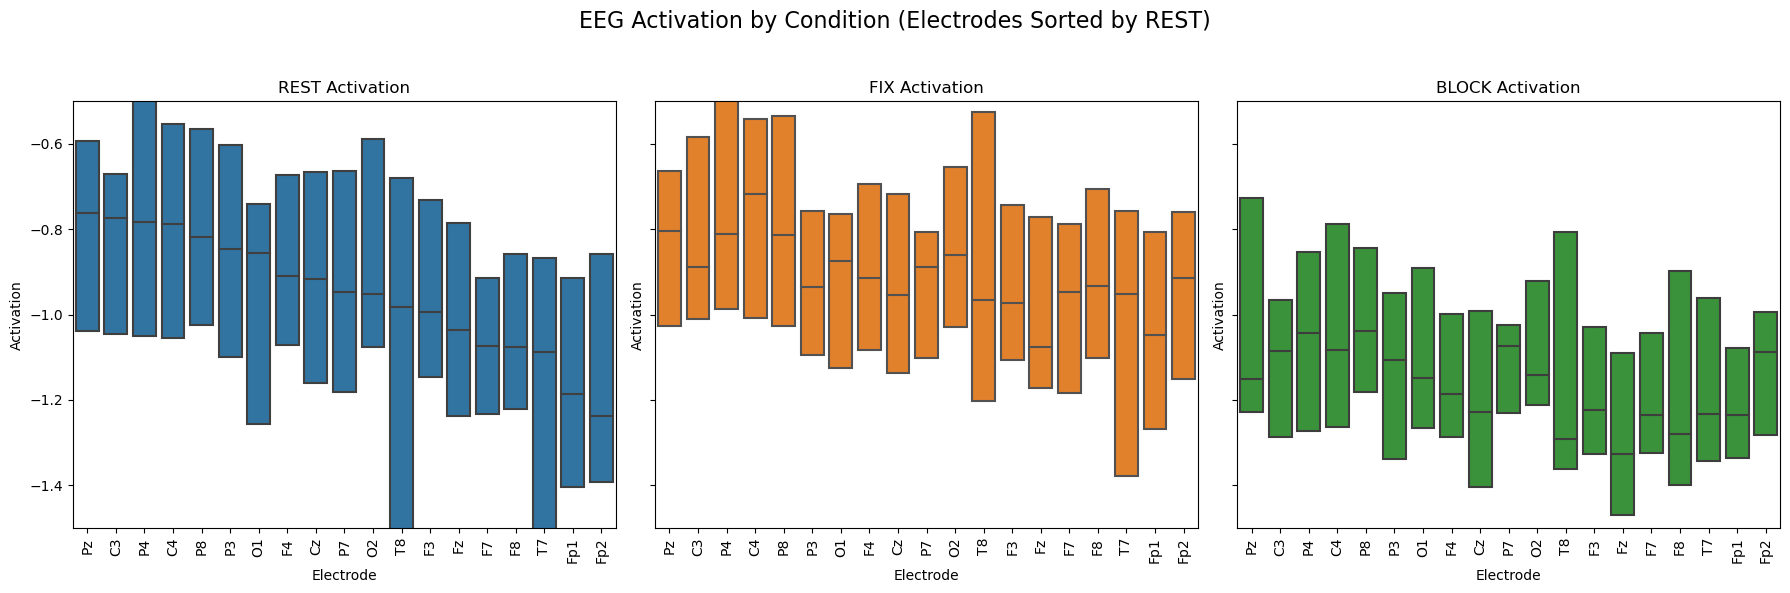

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

#sns.set(style="whitegrid")

# --- Step 1: Compute mean REST per electrode ---
n_electrodes = rest_all.shape[1]
rest_means = {}
data = []
labels = []
electrode_ids = []

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    rest_means[electrodes[e]] = np.median(rest_per_subj)

    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrode_ids.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrode_ids.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrode_ids.extend([electrodes[e]] * len(block_per_subj))

# --- Step 2: Create DataFrame ---
df = pd.DataFrame({
    'Activation': data,
    'Condition': labels,
    'Electrode': electrode_ids
})

# --- Step 3: Sort electrodes based on REST ---
sorted_electrodes = sorted(rest_means, key=rest_means.get, reverse=True)

# --- Step 4: Plot 3 panels ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

conditions = ['REST', 'FIX', 'BLOCK']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # seaborn-like

for ax, cond, color in zip(axes, conditions, colors):
    sns.boxplot(
        data=df[df['Condition'] == cond],
        x='Electrode',
        y='Activation',
        order=sorted_electrodes,
        ax=ax,
        color=color,
        showfliers=False,
        showmeans=False,
        showcaps=False,  # remove end caps
        whiskerprops={'linewidth': 0}
    )

    ax.set_title(f'{cond} Activation')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylim(-1.5, -0.5)

fig.suptitle('EEG Activation by Condition (Electrodes Sorted by REST)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [34]:
sorted_electrodes

['Pz',
 'C3',
 'P4',
 'C4',
 'P8',
 'P3',
 'O1',
 'F4',
 'Cz',
 'P7',
 'O2',
 'T8',
 'F3',
 'Fz',
 'F7',
 'F8',
 'T7',
 'Fp1',
 'Fp2']

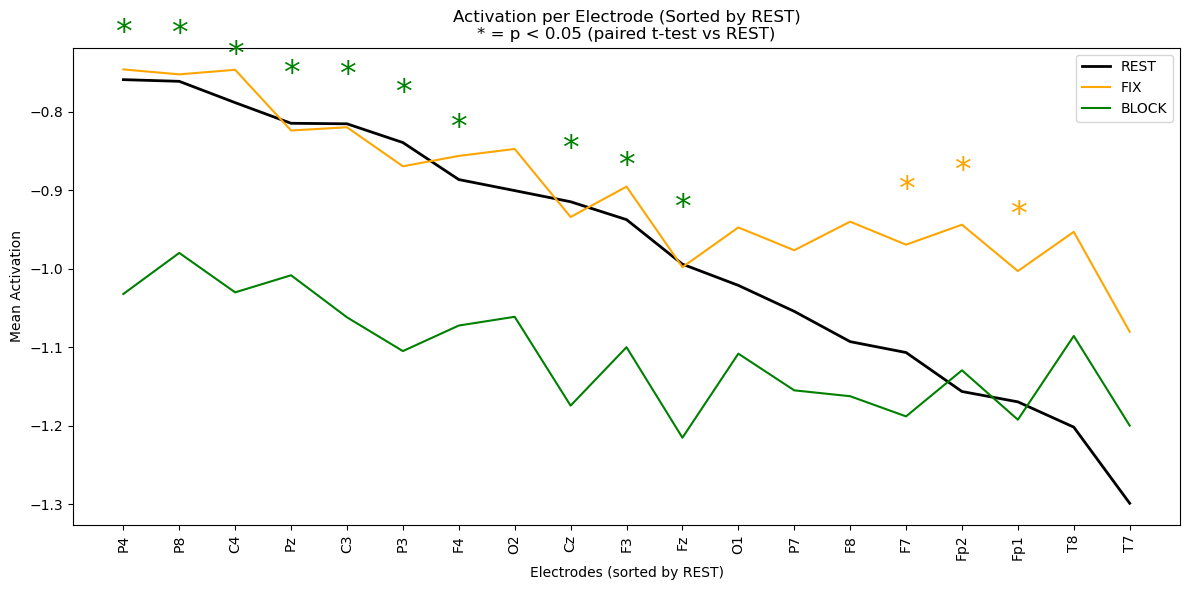

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# === 1. Compute mean activation per electrode ===
rest_means = {electrodes[e]: rest_all[:, e, :].mean() for e in range(len(electrodes))}
fix_means  = {electrodes[e]: fix_all[:, e, :].mean() for e in range(len(electrodes))}
block_means = {electrodes[e]: block_all[:, e, :].mean() for e in range(len(electrodes))}

# === 2. Sort electrodes by REST mean ===
sorted_electrodes = sorted(rest_means, key=rest_means.get, reverse=True)

# === 3. Extract sorted mean values ===
rest_vals  = np.array([rest_means[e] for e in sorted_electrodes])
fix_vals   = np.array([fix_means[e] for e in sorted_electrodes])
block_vals = np.array([block_means[e] for e in sorted_electrodes])

# === 4. Paired t-tests: REST vs FIX and REST vs BLOCK ===
p_fix = []
p_block = []
for e in sorted_electrodes:
    idx = electrodes.index(e)
    rest_subj = rest_all[:, idx, :].mean(axis=1)
    fix_subj  = fix_all[:, idx, :].mean(axis=1)
    block_subj = block_all[:, idx, :].mean(axis=1)

    _, p_f = ttest_rel(fix_subj, rest_subj)
    _, p_b = ttest_rel(block_subj, rest_subj)
    
    p_fix.append(p_f)
    p_block.append(p_b)

# === 5. Plot with significance stars ===
plt.figure(figsize=(12, 6))
x = np.arange(len(sorted_electrodes))

# Plot condition lines
plt.plot(x, rest_vals, label='REST', color='black', linewidth=2)
plt.plot(x, fix_vals, label='FIX', color='orange')
plt.plot(x, block_vals, label='BLOCK', color='green')

# Add stars for significant differences
for i, (p_f, p_b) in enumerate(zip(p_fix, p_block)):
    # Star for FIX vs REST
    if p_f < 0.05:
        y = max(rest_vals[i], fix_vals[i]) + 0.05 * np.abs(max(rest_vals[i], fix_vals[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='orange', fontsize=24)

    # Star for BLOCK vs REST
    if p_b < 0.05:
        y = max(rest_vals[i], block_vals[i]) + 0.05 * np.abs(max(rest_vals[i], block_vals[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='green', fontsize=24)

# Final plot settings
plt.xticks(x, sorted_electrodes, rotation=90)
plt.xlabel('Electrodes (sorted by REST)')
plt.ylabel('Mean Activation')
plt.title('Activation per Electrode (Sorted by REST)\n* = p < 0.05 (paired t-test vs REST)')
plt.legend()
plt.tight_layout()
plt.show()


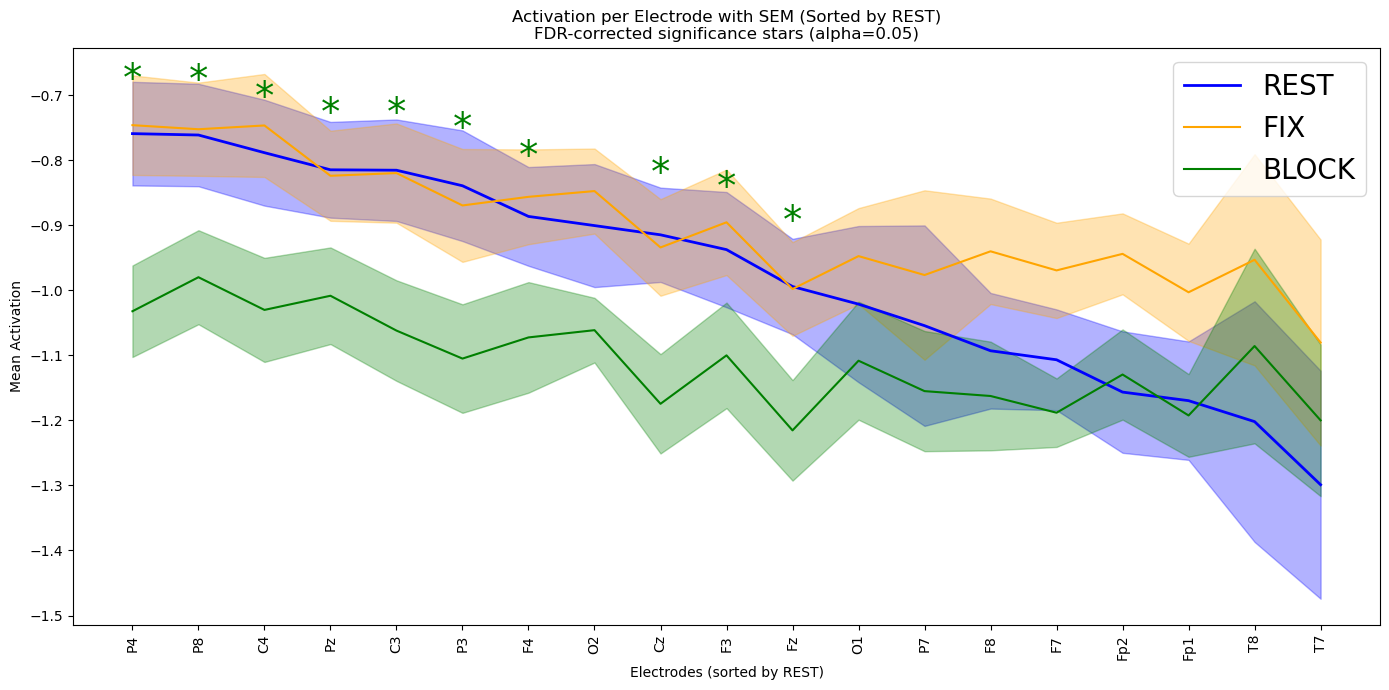

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, sem
from statsmodels.stats.multitest import multipletests

# === Compute mean and SEM per electrode in sorted order ===
def mean_and_sem(data, electrodes_order):
    means = []
    sems = []
    for e in electrodes_order:
        idx = electrodes.index(e)
        vals = data[:, idx, :].mean(axis=1)  # mean across timepoints per subject
        means.append(np.mean(vals))          # mean across subjects
        sems.append(sem(vals))                # sem across subjects
    return np.array(means), np.array(sems)

# === Prepare sorted electrodes and corresponding means/sems ===
rest_mean, rest_sem = mean_and_sem(rest_all, sorted_electrodes)
fix_mean, fix_sem = mean_and_sem(fix_all, sorted_electrodes)
block_mean, block_sem = mean_and_sem(block_all, sorted_electrodes)

# === Perform paired t-tests REST vs FIX and REST vs BLOCK ===
p_fix = []
p_block = []
for e in sorted_electrodes:
    idx = electrodes.index(e)
    rest_subj = rest_all[:, idx, :].mean(axis=1)
    fix_subj  = fix_all[:, idx, :].mean(axis=1)
    block_subj = block_all[:, idx, :].mean(axis=1)

    _, p_f = ttest_rel(fix_subj, rest_subj)
    _, p_b = ttest_rel(block_subj, rest_subj)
    
    p_fix.append(p_f)
    p_block.append(p_b)

p_fix = np.array(p_fix)
p_block = np.array(p_block)

# === FDR correction (Benjamini-Hochberg) ===
rej_fix, pval_fix_corrected, _, _ = multipletests(p_fix, alpha=0.05, method='fdr_bh')
rej_block, pval_block_corrected, _, _ = multipletests(p_block, alpha=0.05, method='fdr_bh')

sig_fix = rej_fix
sig_block = rej_block

# === Plotting ===
x = np.arange(len(sorted_electrodes))
plt.figure(figsize=(14, 7))

# Plot means and SEM shaded areas
plt.plot(x, rest_mean, label='REST', color='blue', linewidth=2)
plt.fill_between(x, rest_mean - rest_sem, rest_mean + rest_sem, color='blue', alpha=0.3)

plt.plot(x, fix_mean, label='FIX', color='orange')
plt.fill_between(x, fix_mean - fix_sem, fix_mean + fix_sem, color='orange', alpha=0.3)

plt.plot(x, block_mean, label='BLOCK', color='green')
plt.fill_between(x, block_mean - block_sem, block_mean + block_sem, color='green', alpha=0.3)

# Add stars for significant differences after FDR correction
for i in range(len(sorted_electrodes)):
    if sig_fix[i]:
        y = max(rest_mean[i], fix_mean[i]) + 0.07 * abs(max(rest_mean[i], fix_mean[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='orange', fontsize=28)
    if sig_block[i]:
        y = max(rest_mean[i], block_mean[i]) + 0.07 * abs(max(rest_mean[i], block_mean[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='green', fontsize=28)

# Labels and formatting
plt.xticks(x, sorted_electrodes, rotation=90)
plt.xlabel('Electrodes (sorted by REST)')
plt.ylabel('Mean Activation')
plt.title('Activation per Electrode with SEM (Sorted by REST)\nFDR-corrected significance stars (alpha=0.05)')
plt.legend(fontsize=20)
plt.tight_layout()
plt.grid(False)
plt.show()


In [37]:
rest_mean

array([-0.75899005, -0.76113214, -0.78830278, -0.81461181, -0.81526534,
       -0.83915316, -0.88631785, -0.90040259, -0.91459772, -0.93737859,
       -0.99413422, -1.02118261, -1.05428843, -1.0928848 , -1.10675257,
       -1.1564358 , -1.16962408, -1.20184257, -1.2988842 ])

In [38]:
block_all.shape

(18, 19, 9)

In [39]:
np.save("spec_fix.npy",fix_mean_per_elec)
np.save("spec_block.npy",block_mean_per_elec)
np.save("spec_rest.npy",rest_mean_per_elec)

np.save("spec_rest_all.npy",rest_all)
np.save("spec_fix_all.npy",fix_all)
np.save("spec_block_all.npy",block_all)

C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

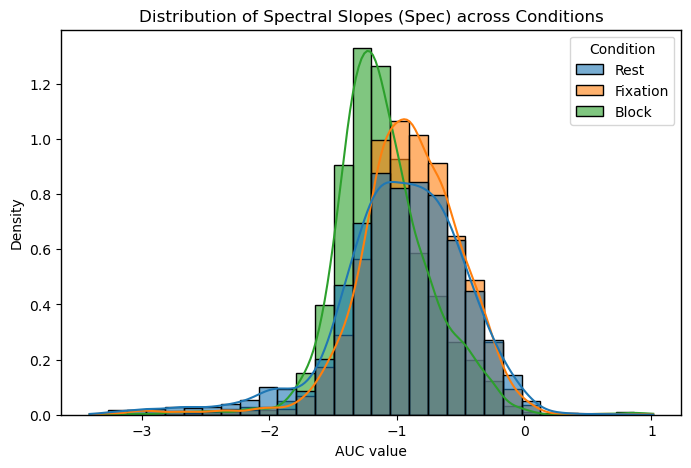

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Flatten electrodes & blocks per subject, then concatenate subjects
def flatten_data(arr):
    return arr.reshape(arr.shape[0], -1)  # (subjects, electrodes * blocks)

rest_flat = flatten_data(rest_all)
fix_flat = flatten_data(fix_all)
block_flat = flatten_data(block_all)

# Combine all data into one DataFrame for seaborn
df = pd.DataFrame({
    'Value': np.concatenate([rest_flat.flatten(), fix_flat.flatten(), block_flat.flatten()]),
    'Condition': ['Rest'] * rest_flat.size + ['Fixation'] * fix_flat.size + ['Block'] * block_flat.size
})

plt.figure(figsize=(8, 5))
plt.grid(False)

sns.histplot(data=df, x='Value', hue='Condition', bins=30, kde=True, stat='density', common_norm=False, alpha=0.6)
plt.title("Distribution of Spectral Slopes (Spec) across Conditions")
plt.xlabel("AUC value")
plt.ylabel("Density")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)
plt.show()


In [41]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

pairs = [
    ('Rest', 'Fixation'),
    ('Rest', 'Block'),
    ('Fixation', 'Block')
]

p_vals = []
for cond1, cond2 in pairs:
    data1 = df[df['Condition'] == cond1]['Value']
    data2 = df[df['Condition'] == cond2]['Value']
    stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
    p_vals.append(p)
    print(f"{cond1} vs {cond2}: U = {stat:.2f}, raw p = {p:.4g}")

# Bonferroni correction
_, p_corrected, _, _ = multipletests(p_vals, method='bonferroni')

print("\nBonferroni-corrected p-values:")
for i, (cond1, cond2) in enumerate(pairs):
    print(f"{cond1} vs {cond2}: corrected p = {p_corrected[i]:.4g}")


Rest vs Fixation: U = 4381998.00, raw p = 3.536e-07
Rest vs Block: U = 5903337.00, raw p = 8.186e-63
Fixation vs Block: U = 6434565.00, raw p = 6.174e-131

Bonferroni-corrected p-values:
Rest vs Fixation: corrected p = 1.061e-06
Rest vs Block: corrected p = 2.456e-62
Fixation vs Block: corrected p = 1.852e-130


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


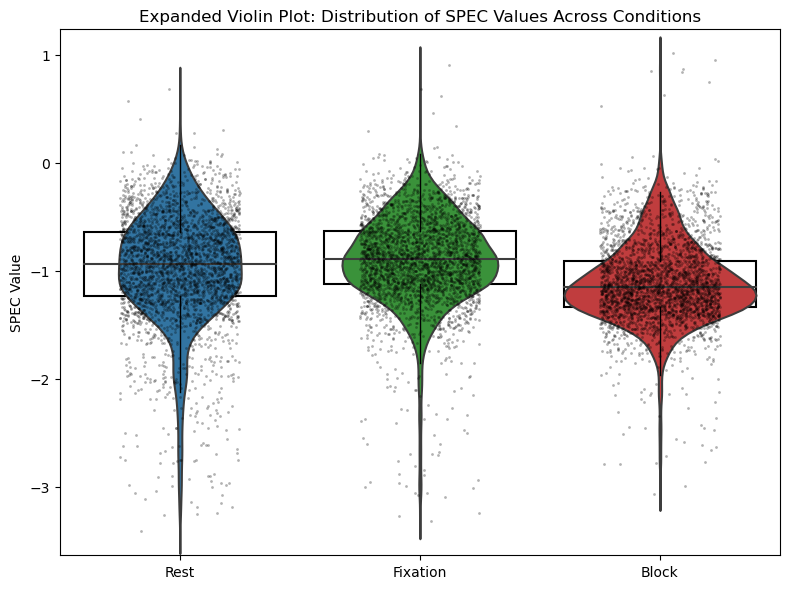

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set custom color palette for consistency
palette = {"Rest": "#1f77b4", "Fixation": "#2ca02c", "Block": "#d62728"}

plt.figure(figsize=(8, 6))

# Violin plot with color per condition
sns.violinplot(data=df, x='Condition', y='Value', inner=None, palette=palette)

# Stripplot for datapoints
sns.stripplot(data=df, x='Condition', y='Value',
              jitter=0.25, size=2, alpha=0.3, color='black')

# Boxplot overlay (outline only)
sns.boxplot(data=df, x='Condition', y='Value',
            showcaps=False,
            boxprops={'facecolor': 'none', 'edgecolor': 'black'},
            whiskerprops={'linewidth': 1, 'color': 'black'},
            showfliers=False)

plt.title("Expanded Violin Plot: Distribution of SPEC Values Across Conditions")
plt.ylabel("SPEC Value")
plt.xlabel("")
plt.tight_layout()
plt.show()


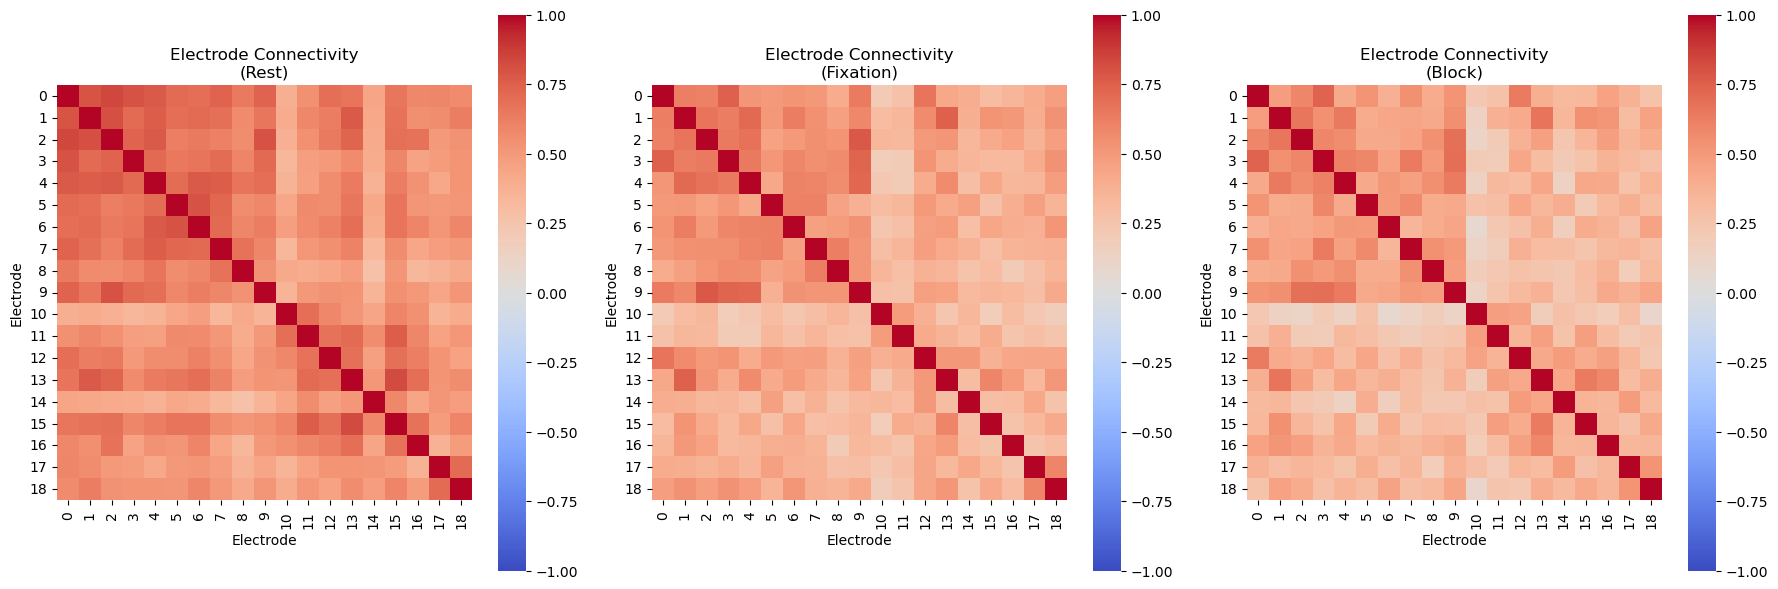

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assume your data shapes are (subjects, electrodes, time_points):
# rest_all, fix_all, block_all

def electrode_connectivity_matrix(data):
    """
    Compute electrodes x electrodes correlation matrix for one subject.
    data shape: (electrodes, time_points)
    Returns: electrodes x electrodes correlation matrix
    """
    # Compute Pearson correlation between electrode signals across time
    corr_mat = np.corrcoef(data)
    return corr_mat

def average_connectivity_across_subjects(data_all):
    """
    data_all shape: (subjects, electrodes, time_points)
    Returns average electrodes x electrodes connectivity matrix
    """
    n_subjects = data_all.shape[0]
    n_electrodes = data_all.shape[1]
    avg_corr = np.zeros((n_electrodes, n_electrodes))
    count = 0
    for subj in range(n_subjects):
        subj_data = data_all[subj, :, :]
        if np.isnan(subj_data).any():
            continue
        corr_mat = electrode_connectivity_matrix(subj_data)
        avg_corr += corr_mat
        count += 1
    return avg_corr / max(count, 1)

# Compute average connectivity matrices
rest_conn = average_connectivity_across_subjects(rest_all)
fix_conn = average_connectivity_across_subjects(fix_all)
block_conn = average_connectivity_across_subjects(block_all)

# Plot side-by-side
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, mat, cond in zip(axs, [rest_conn, fix_conn, block_conn], ['Rest', 'Fixation', 'Block']):
    sns.heatmap(mat, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar=True)
    ax.set_title(f'Electrode Connectivity\n({cond})')
    ax.set_xlabel('Electrode')
    ax.set_ylabel('Electrode')

plt.tight_layout()
plt.show()
